# Veri Bilimi
* **Veri Bilimi Nedir?**
    * Veri bilimi, yapılandırılmış ve yapılandırılmamış verilerden bilgi ve öngörü elde etmek için bilimsel yöntemleri, süreçleri ve algoritmaları kullanan çok disiplinli bir alandır. 
    * Veri bilimi, yapay zeka yada makine öğrenmesi gibi konulardan ayrı düşünülemez. 
    <br> <br>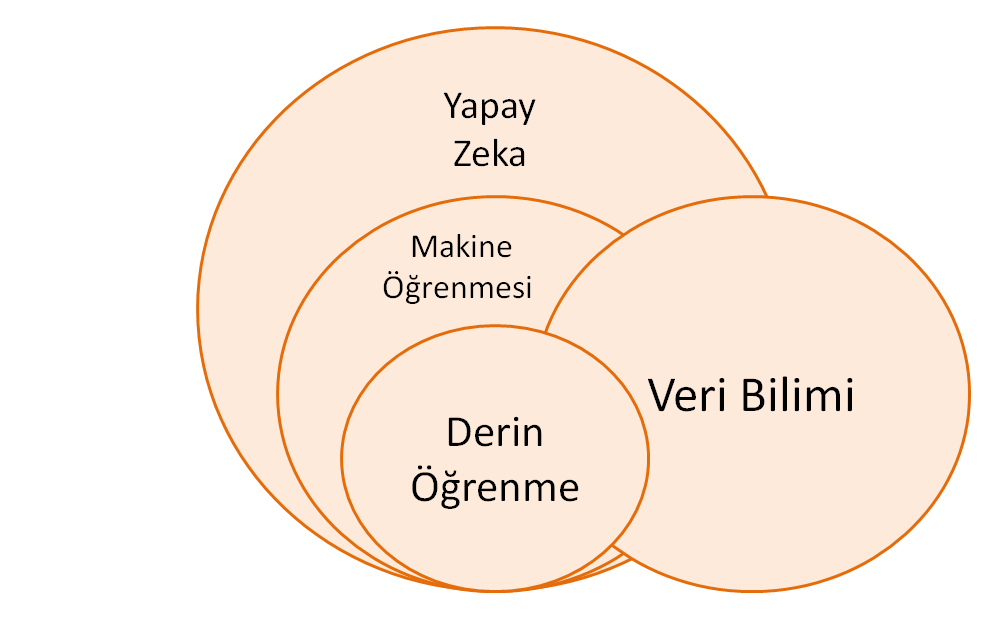
    * Veri bilimi ile alakalı ortak disiplinler istatistik, matematik, örüntü tanıma, veri madenciliği, makine öğrenmesi, yapay zeka, sinir ağları, veri görselleştirme, veri modelleme, büyük veri ve keşifsel veri analizidir.
    <br><br>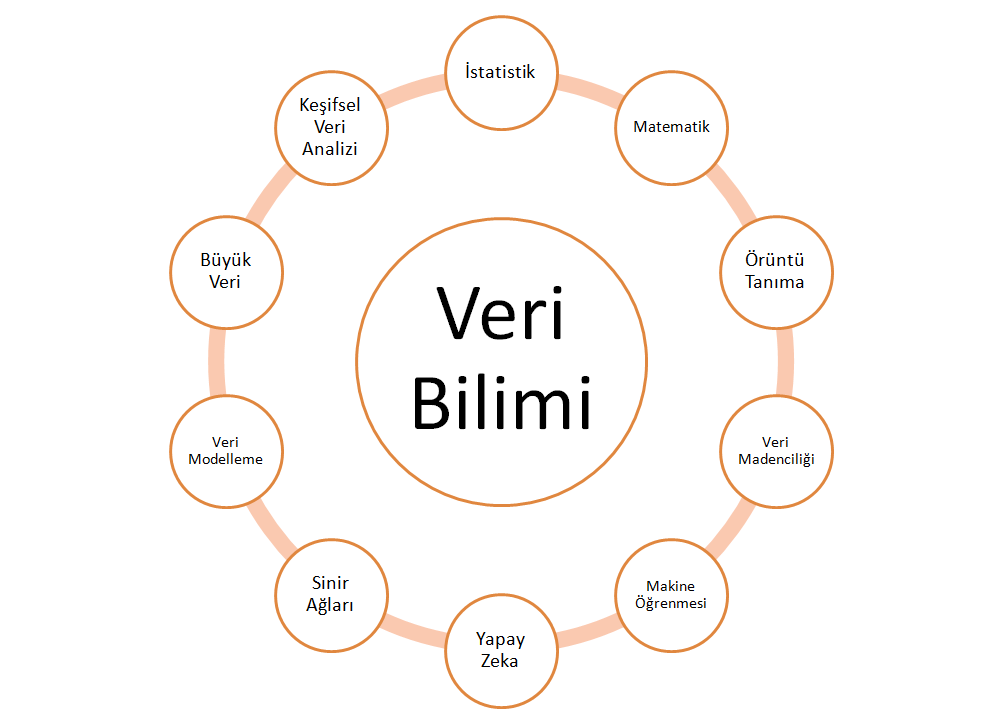


<br><br>**İçerik:**
1. [120 Yıllık Olimpiyat Tarihi Veri Seti](#1)
    * Veri Hakkında Bilgi
1. [Verinin Temizlenmesi](#2)
    * Sütun İsimlerinin Düzenlenmesi
    * Yararsız Verinin Çıkarılması ve Düzenlenmesi
    * Kayıp Veri Sorunu 
1. [Tek Değişkenli Veri Analizi](#3)
    * Sayısal Değişkenler
    * Kategorik Değişkenler
1. [İki Değişkenli Veri Analizi](#4)
1. [Çok Değişkenli Veri Analizi](#5)
    * groupby - melting/pivoting falan burada yapılabilir
1. [Anomali Tespiti](#6)
1. [Zaman Serilerinde Veri Analizi](#7)

<a id='1'></a>
## 120 Yıllık Olimpiyat Tarihi Veri Seti

* 120 Yıllık Olimpiyat Tarihi Veri Seti, Atina 1896'dan Rio 2016'ya kadar tüm oyunlar da dahil olmak üzere modern Olimpiyat Oyunlarına ilişkin tarihsel bir veri kümesidir.

* Veri seti içerisinde bulunan sütunların isimleri ve açıklamaları
    1. ID - Her sporcu için benzersiz numara
    1. Name - Sporcunun ismi
    1. Gender - Cinsiyet: M(Erkek) - F(Kadın)
    1. Age - Yaş
    1. Height - Boy (santimetre)
    1. Weight - Ağırlık (Kilogram)
    1. Team - Takım ismi
    1. NOC - Ulusal Olimpiyat Komitesi 3 harfli kod
    1. Games - Yıl ve sezon
    1. Year - Yıl
    1. Season - Sezon: Yaz ya da Kış
    1. City - Düzenlenen Şehir
    1. Sport - Spor
    1. Event - Etkinlik
    1. Medal - Madalya: Altın, Gümüş, Bronz ve Madalya Yok

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# pythonda uyarıları kapatır
import warnings
warnings.filterwarnings("ignore")

In [2]:
veri=pd.read_csv("olimpiyatlar.csv")
veri.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


### Veri Hakkında Bilgi
* Bu bölümde veri içerisinde bulunan her bir sütun içerisinde kaç adet örnek var, bu verilerin veri tipleri nedir ve veri tiplerinin tüm veri içerisinde dağılımı nedir gibi veriyi tanımak için gerekli temel soruları cevaplayacağız.


In [3]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


<a id='2'></a>
## Verinin Temizlenmesi
* Sütun İsimlerinin Düzenlenmesi
* Yararsız Verinin Çıkarılması ve Düzenlenmesi
* Kayıp Veri Sorunu 

In [4]:
veri.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

### Sütun İsimlerinin Düzenlenmesi
* Bu bölümde veri içerisinde bulunan sütun isimlerini inceleyeceğiz ve bu isimleri Türkçeye çevireceğiz.

In [5]:
veri.rename(columns={'ID':'id',
                    'Name':'isim',
                    'Sex':'cinsiyet',
                    'Age':'yas',
                    'Height':'boy',
                    'Weight':'kilo',
                    'Team':'takim',
                    'NOC':'kod',
                    'Games':'oyunlar',
                    'Year':'yil',
                    'Season':'sezon',
                    'City':'sehir',
                    'Sport':'spor',
                    'Event':'etkinlik',
                    'Medal':'madalya'},inplace=True)
veri.head(2)

,id,isim,cinsiyet,yas,boy,kilo,takim,kod,oyunlar,yil,sezon,sehir,spor,etkinlik,madalya
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN


### Yararsız Verinin Çıkarılması ve Düzenlenmesi
* id sütunu veri hakkında herhangi bir bilgi vermediği için çıkarılacaktır.
* oyunlar sütunu yıl ve sezon sütunlarının birleşimi olduğu için yararsız veri olarak kabul edilir ve çıkarılabilir.

In [6]:
veri=veri.drop(['id','oyunlar'],axis=1)


In [7]:
veri.head(3)

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
0,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,NaN


### Kayıp Veri Sorunu 
* Kayıp veri kavramı veri içerisinde bulunan örneğin herhangi bir sütununda bulunan değerin olmaması anlamına gelir. 
* Mesela, aşağıda bulunan veride ikinci index'te bulunan örneğin boy ve kilo sütunlarında NaN (Not a Number) yazmaktadır. Bu NaN yazısı örneğe ait boy ve kilo verisinin olmadığı ya da kayıp olduğu anlamına gelir.

* Kayıp veri ile mücadele etmek için,
    1. Kayıp veriye ait örnekler veriden çıkarılabilir.
    1. Kayıp veriler asıl verinin dağılımını bozmayacak şekilde asıl verinin ortalama ya da medyan değerlerine göre doldurulabilir.
* Bu veri üzerinde çalışma yaparken, 
    1. Boy ve kilo sütununda bulunan kayıp veriyiyi etkinlik ortalamasına göre dolduracağız.
    1. Yaş sütununda bulunan kayıp veriyi veri setinin yaş ortalamasına göre dolduracağız.
    1. Madalya alamayan sporcuları veri setinden çıkaracağız.

### Boy ve Kilo Sütunu Kayıp Veri Doldurma
* Boy ve kilo sütununda bulunan kayıp veriyiyi etkinlik ortalamasına göre dolduracağız.

In [8]:
essiz_etkinlik=pd.unique(veri.etkinlik)
print(f"Eşsiz etkiinlik sayısı={len(essiz_etkinlik)}")
print(essiz_etkinlik[:10])

Eşsiz etkiinlik sayısı=765
["Basketball Men's Basketball" "Judo Men's Extra-Lightweight"
 "Football Men's Football" "Tug-Of-War Men's Tug-Of-War"
 "Speed Skating Women's 500 metres" "Speed Skating Women's 1,000 metres"
 "Cross Country Skiing Men's 10 kilometres"
 "Cross Country Skiing Men's 50 kilometres"
 "Cross Country Skiing Men's 10/15 kilometres Pursuit"
 "Cross Country Skiing Men's 4 x 10 kilometres Relay"]


In [9]:
veri_gecici=veri.copy()
boy_kilo_liste=["boy","kilo"]

for e in essiz_etkinlik:
    etkinlik_filtre=veri_gecici.etkinlik==e
    veri_filtreli=veri_gecici[etkinlik_filtre]
    for s in boy_kilo_liste:
        ortalama=np.round(np.mean(veri_filtreli[s]),2)
        if ~np.isnan(ortalama):
            veri_filtreli[s]=veri_filtreli[s].fillna(ortalama)
        else:
            tüm_ortalama=np.round(np.mean(veri_gecici[s]),2)
            veri_filtreli[s]=veri_filtreli[s].fillna(tüm_ortalama)
    veri_gecici[etkinlik_filtre]=veri_filtreli

veri=veri_gecici.copy()

                                  



In [10]:
veri.head(5)
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   isim      271116 non-null  object 
 1   cinsiyet  271116 non-null  object 
 2   yas       261642 non-null  float64
 3   boy       271116 non-null  float64
 4   kilo      271116 non-null  float64
 5   takim     271116 non-null  object 
 6   kod       271116 non-null  object 
 7   yil       271116 non-null  int64  
 8   sezon     271116 non-null  object 
 9   sehir     271116 non-null  object 
 10  spor      271116 non-null  object 
 11  etkinlik  271116 non-null  object 
 12  madalya   39783 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 26.9+ MB


### Yaş Sütunu Kayıp Veri Doldurma
* Yaş sütununda bulunan kayıp veriyi veri setinin yaş ortalamasına göre dolduracağız.

In [11]:
yas_ortalamasi=np.round(np.mean(veri.yas),2)
veri.yas.fillna(yas_ortalamasi,inplace=True)

In [12]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   isim      271116 non-null  object 
 1   cinsiyet  271116 non-null  object 
 2   yas       271116 non-null  float64
 3   boy       271116 non-null  float64
 4   kilo      271116 non-null  float64
 5   takim     271116 non-null  object 
 6   kod       271116 non-null  object 
 7   yil       271116 non-null  int64  
 8   sezon     271116 non-null  object 
 9   sehir     271116 non-null  object 
 10  spor      271116 non-null  object 
 11  etkinlik  271116 non-null  object 
 12  madalya   39783 non-null   object 
dtypes: float64(3), int64(1), object(9)
memory usage: 26.9+ MB


### Madalya Alamayan Sporcuları Veri Setinden Çıkar
* Madalya alamayan sporcuları veri setinden çıkaracağız.

In [13]:
madalya_degiskeni=veri.madalya
pd.isnull(madalya_degiskeni).sum()

np.int64(231333)

In [14]:
madalya_alan_filtresi=~pd.isnull(madalya_degiskeni)
veri=veri[madalya_alan_filtresi]
veri.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39783 entries, 3 to 271103
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   isim      39783 non-null  object 
 1   cinsiyet  39783 non-null  object 
 2   yas       39783 non-null  float64
 3   boy       39783 non-null  float64
 4   kilo      39783 non-null  float64
 5   takim     39783 non-null  object 
 6   kod       39783 non-null  object 
 7   yil       39783 non-null  int64  
 8   sezon     39783 non-null  object 
 9   sehir     39783 non-null  object 
 10  spor      39783 non-null  object 
 11  etkinlik  39783 non-null  object 
 12  madalya   39783 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 4.2+ MB


In [15]:
# Önümüzdeki derslerde kullanmak için veriyi kaydet
veri.to_csv("olimpiyatlar_madalya_alanlar.csv",index=False)

<a id='3'></a>
## Tek Değişkenli Veri Analizi
Bu bölümde veri içerisinde bulunan sayısal ve kategorik verilerin tek tek incelemesini yapacağız.
* Sayısal Değişkenler:
    1. yas   
    1. boy
    1. kilo
    1. yil
* Kategorik Değişkenler:
    1. isim
    1. cinsiyet
    1. takim
    1. UOK
    1. sezon
    1. sehir
    1. spor
    1. etkinlik
    1. madalya

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# pythonda uyarıları kapatır
import warnings
warnings.filterwarnings("ignore")
veri=pd.read_csv("olimpiyatlar_madalya_alanlar.csv")

In [17]:
veri.head()

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
0,Edgar Lindenau Aabye,M,34.0,182.48,95.62,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
1,Arvo Ossian Aaltonen,M,30.0,182.01,76.69,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
2,Arvo Ossian Aaltonen,M,30.0,177.00,75.00,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
3,Juhamatti Tapio Aaltonen,M,28.0,184.00,85.00,Finland,FIN,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
4,Paavo Johannes Aaltonen,M,28.0,175.00,64.00,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [18]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39783 entries, 0 to 39782
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   isim      39783 non-null  object 
 1   cinsiyet  39783 non-null  object 
 2   yas       39783 non-null  float64
 3   boy       39783 non-null  float64
 4   kilo      39783 non-null  float64
 5   takim     39783 non-null  object 
 6   kod       39783 non-null  object 
 7   yil       39783 non-null  int64  
 8   sezon     39783 non-null  object 
 9   sehir     39783 non-null  object 
 10  spor      39783 non-null  object 
 11  etkinlik  39783 non-null  object 
 12  madalya   39783 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 3.9+ MB


### Sayısal Değişkenler
* Veri içerisinde 4 adet sayısal değişken bulunmaktadır. Bunlar:     
    1. yas   
    1. boy
    1. kilo
    1. yil
* Sayısal değişkenleri incelemek ve yorumlamak için veri sıkılığı ve temel istatistik bilgilerini kullanacağız.
* Veri sıklığı bilgilerini histogram gradiği sayesinde inceleyeceğiz.
* Temel istatistik bilgilerini ise kutu grafiği sayesinde yorumlayacağız.

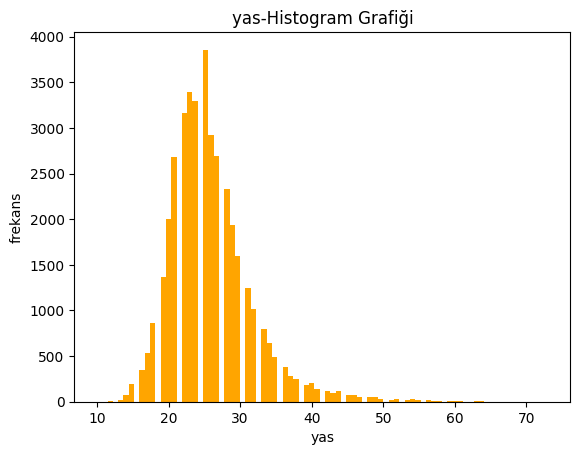

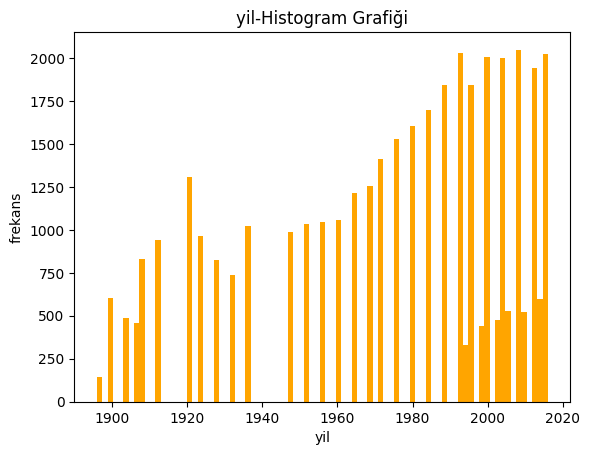

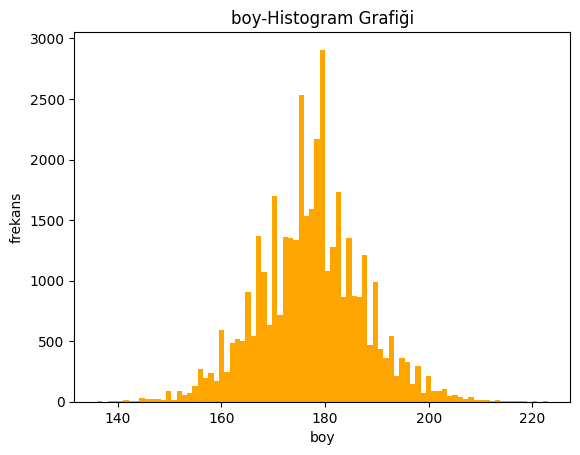

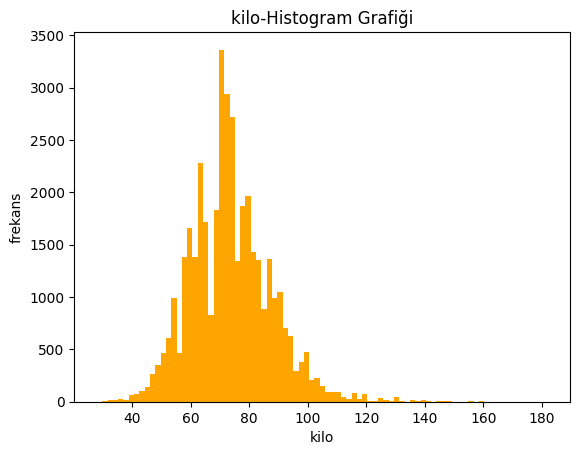

In [19]:
def plotHistogram(degisken): # degisken hangi sütunun histogramını( histogram verinin dağılımını gösteren çubuk grafiğidir) çiziceğimizi belirtir.
    plt.figure() # her çağrıda yeni temiz bir grafik oluşturur.
    plt.hist(veri[degisken],bins=85,color="orange") # bins çubukların sayısını belirliyor( veriyi kaça bölüceğimizi belirtiyor ne kadar fazla ise çubuk o kadar ince oluyor), color ise rengi belirtiyor.
    plt.xlabel(degisken)
    plt.ylabel("frekans")
    plt.title(f"{degisken}-Histogram Grafiği")
    plt.show()
    
sayisal_degiskenler=["yas","yil","boy","kilo"]
for elem in sayisal_degiskenler:
    plotHistogram(elem)

* Beklenildiği gibi yaş, kilo ve boy sütunlarında normal dağılıma yakın bir dağılım söz konusu. 
* Yıl sütununda ise ilk olarak göze çarpan son yüzyılda gerçekleşen savaş zamanlarında olimpiyatların yapılmadığı ve son 20 yılda olimpiyatların eski yıllara göre daha çok yapıldığıdır.

In [20]:
# veri içerisinde bulunan sayısal değerleri istatistiksel açıdan inceleyelim
veri.describe()

,yas,boy,kilo,yil
count,39783.000000,39783.000000,39783.000000,39783.000000
mean,25.918456,177.337864,73.751840,1973.943845
std,5.859569,10.169900,13.976279,33.822857
min,10.000000,136.000000,28.000000,1896.000000
25%,22.000000,170.000000,64.000000,1952.000000
50%,25.000000,177.480000,73.000000,1984.000000
75%,29.000000,184.000000,82.000000,2002.000000
max,73.000000,223.000000,182.000000,2016.000000


* Sayısal verinin istatistiksel özellikleri
    1. count: Örnek sayısı
    1. mean: Ortalama
    1. std: Standart sapma
    1. min: Minimum değer
    1. 25%: Birinci çeyrek
    1. 50%: Medyan
    1. 75%: Üçüncü çeyrek
    1. max: Maximum değer
* 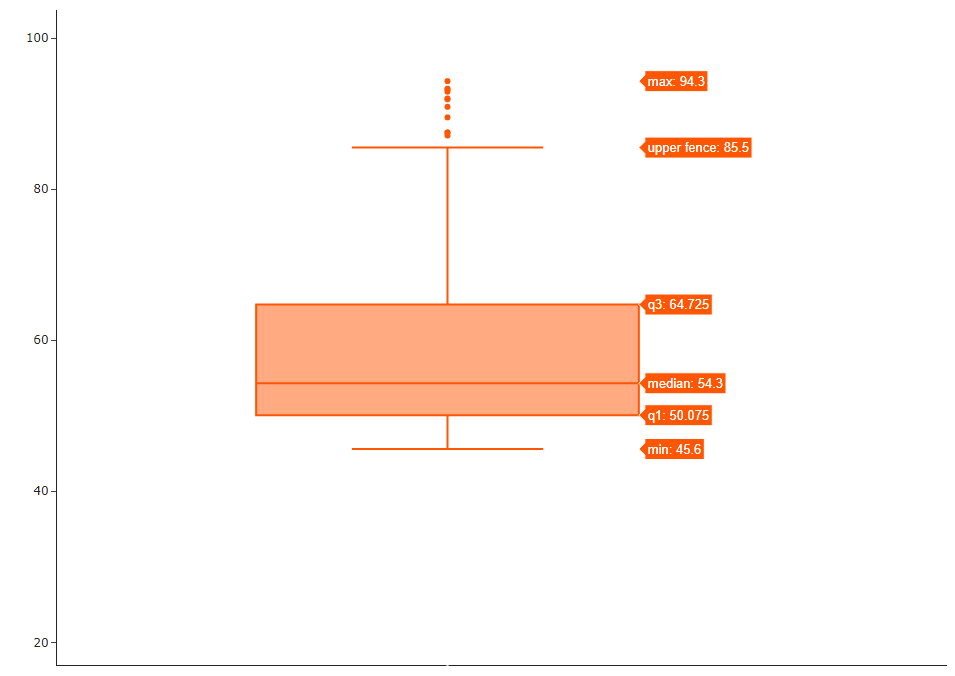

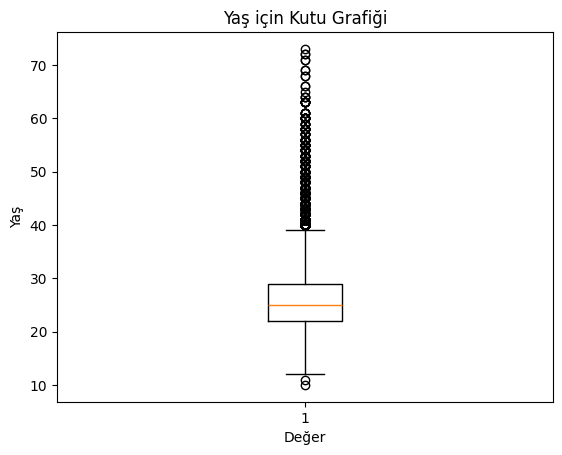

In [21]:
plt.boxplot(veri.yas)
plt.title("Yaş için Kutu Grafiği")
plt.ylabel("Yaş")
plt.xlabel("Değer")
plt.show()

### Kategorik Değişkenler
* Veri içerisinde 9 adet kategorik değişken bulunmaktadır. Bunlar:
    1. isim
    1. cinsiyet
    1. takim
    1. uok
    1. sezon
    1. sehir
    1. spor
    1. etkinlik
    1. madalya
* Kategorik değişkenleri incelemek ve yorumlamak için bar grafiklerini kullanacağız.

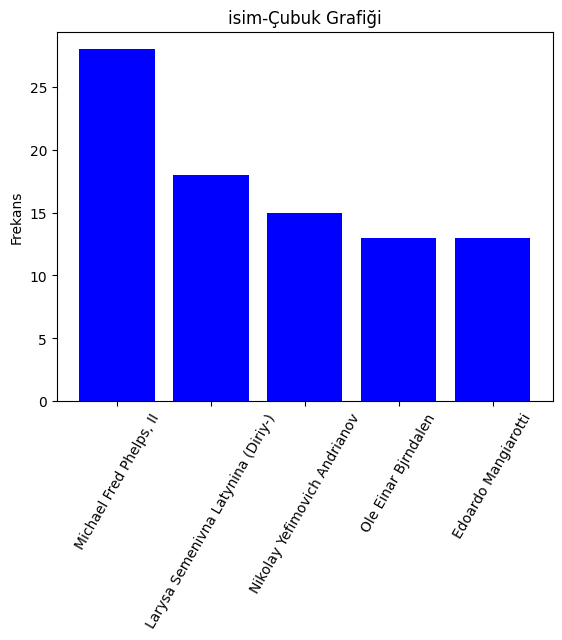

isim Analizi:
isim
Michael Fred Phelps, II               28
Larysa Semenivna Latynina (Diriy-)    18
Nikolay Yefimovich Andrianov          15
Ole Einar Bjrndalen                   13
Edoardo Mangiarotti                   13
Name: count, dtype: int64


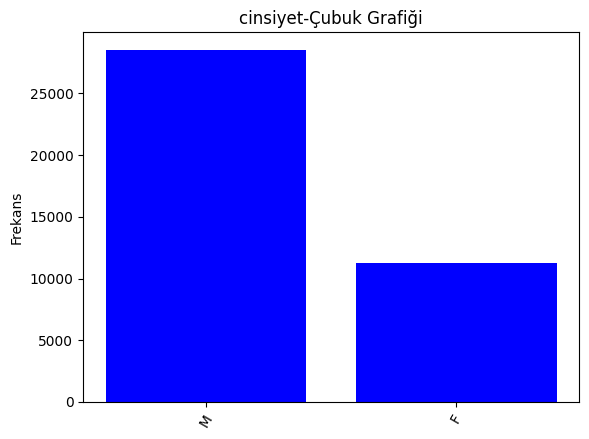

cinsiyet Analizi:
cinsiyet
M    28530
F    11253
Name: count, dtype: int64


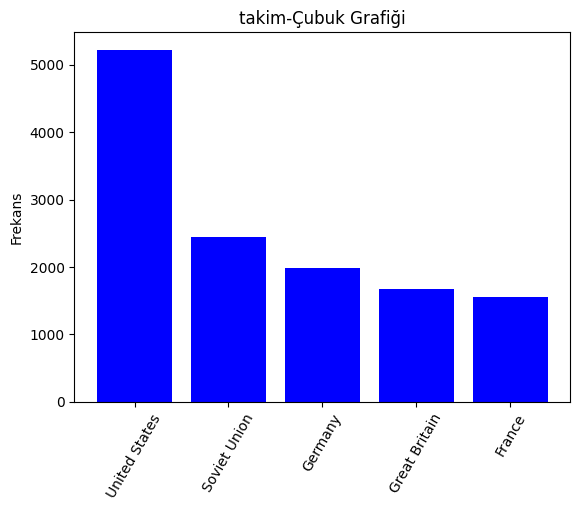

takim Analizi:
takim
United States    5219
Soviet Union     2451
Germany          1984
Great Britain    1673
France           1550
Name: count, dtype: int64


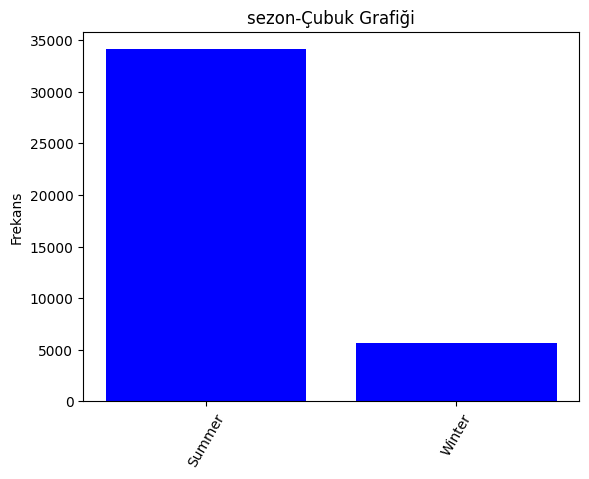

sezon Analizi:
sezon
Summer    34088
Winter     5695
Name: count, dtype: int64


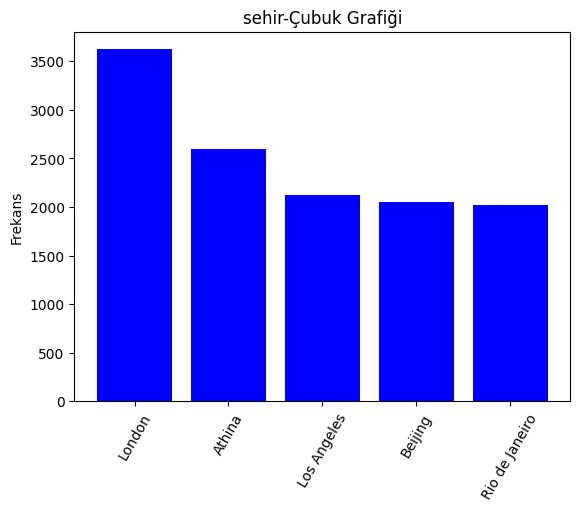

sehir Analizi:
sehir
London            3624
Athina            2602
Los Angeles       2123
Beijing           2048
Rio de Janeiro    2023
Name: count, dtype: int64


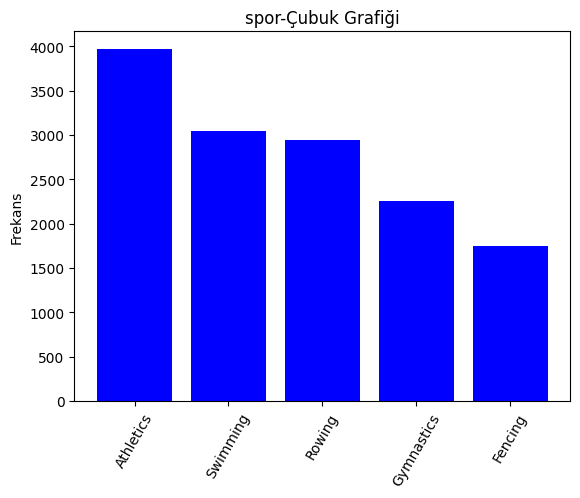

spor Analizi:
spor
Athletics     3969
Swimming      3048
Rowing        2945
Gymnastics    2256
Fencing       1743
Name: count, dtype: int64


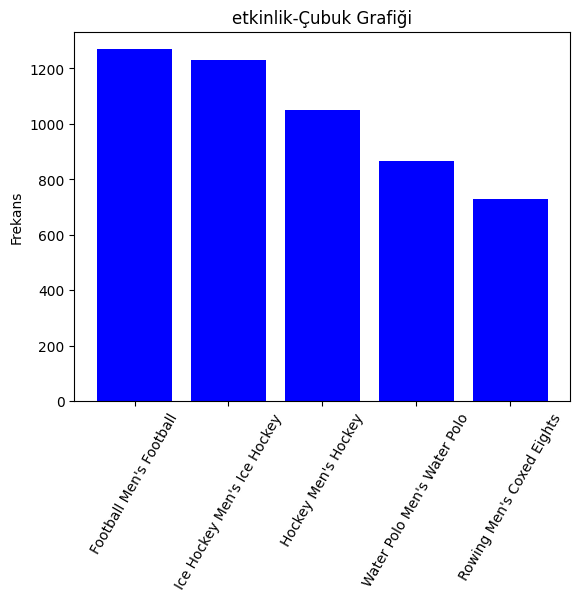

etkinlik Analizi:
etkinlik
Football Men's Football        1269
Ice Hockey Men's Ice Hockey    1230
Hockey Men's Hockey            1050
Water Polo Men's Water Polo     866
Rowing Men's Coxed Eights       730
Name: count, dtype: int64


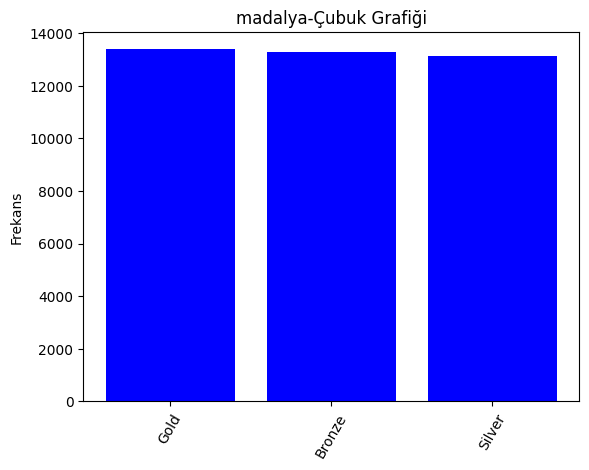

madalya Analizi:
madalya
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64


In [22]:
def plotBar(degisken,n=5):
    veri_sayma=veri[degisken].value_counts()
    veri_sayma=veri_sayma[:n] # ilk n değeri ( varsayılan 5) al
    plt.figure() # yeni temiz bir grafik oluşturur.
    plt.bar(veri_sayma.index,veri_sayma,color="blue") # plt.bar(x eksenei etiketi, y ekseni etkiketi, renk)
    plt.xticks(veri_sayma.index,veri_sayma.index.values) # x satırlarını yeniden ayarlıyor aslında gereksiz ama eksi alışkanlık büyük ihtimalle
    plt.xticks(rotation=60) # yazının rotasyonunu ayarlıyor (derecesini)
    plt.ylabel("Frekans")
    plt.title(f"{degisken}-Çubuk Grafiği")
    plt.show()
    print(f"{degisken} Analizi:\n{veri_sayma}") # grafiklerin altına da sayısal veriyi yazar veya istatistikleri
    

kategorik_degiskenler=["isim","cinsiyet","takim","sezon","sehir","spor","etkinlik","madalya"]
for elem in kategorik_degiskenler:
    plotBar(elem)



* Olimpiyat tarihi boyunca en çok madalya kazanan isim Micheal Phelps'dir.
* Kadın ve erkek yarışmacılar arasında yaklaşık 1:2 oranı görülmektedir.
* Takımlar olarak en çok ABD katılmıştır.
* Beklendiği gibi uok ve takım çıktıları aynıdır.
* Yaz sezonunda düzenlenen olimpiyat sayısı kış sezonunda düzenlenenden fazladır.
* Olimpiyatlar en çok Londra'da düzenlenmiştir.
* Olimpiyatlarda en çok atletizm branşında yarışılmıştır.
* Erkekler futbol müsabakaları en çok yapılan etkinliktir.
* Verilen madalyaların aynı çıkmasını beklerken, farklılık olduğu görülmektedir.

<a id='4'></a>
## İki Değişkenli Veri Analizi
* İki değişkenli veri analizi yaparken kazanılan madalyalar ve diğer sütunlar arasında bulunan ilişkileri inceleyeceğiz.
    1. Cinsiyete göre boy ve kilo karşılaştırması
    1. Saysal sütunlar arasında ilişkinin incelenmesi
    1. Madalya ve yaş arasındaki ilişkinin incelenmesi
    1. Takımların kazandıkları altın, gümüş ve bronz madalya sayıları
    1. Kazanılan madalyaların hangi şehirlerde kazanıldığı
    1. Cinsiyete göre kazanılan altın, gümüş ve bronz madalya sayıları    

### Cinsiyete Göre Boy ve Kilo Karşılaştırması

In [23]:
erkek=veri[veri.cinsiyet=="M"]
kadin=veri[veri.cinsiyet=="F"]
erkek.head(5)

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
0,Edgar Lindenau Aabye,M,34.0,182.48,95.62,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
1,Arvo Ossian Aaltonen,M,30.0,182.01,76.69,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
2,Arvo Ossian Aaltonen,M,30.0,177.00,75.00,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
3,Juhamatti Tapio Aaltonen,M,28.0,184.00,85.00,Finland,FIN,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
4,Paavo Johannes Aaltonen,M,28.0,175.00,64.00,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


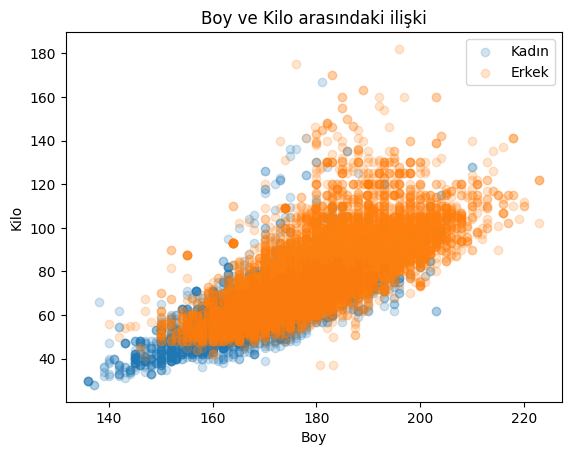

In [24]:
plt.figure()
plt.scatter(kadin.boy,kadin.kilo,alpha=0.2,label="Kadın") #plt.scatter dağılım grafiği çizer.
#kadin.boy ve kadin.kilo sırası ile x ve y ekseni verilerini ayarlar. alpha=0.2 noktalar %20 saydam demek label ise açıklama kutusunda ne yazıdağını ayarlar (sağ üstteki)
plt.scatter(erkek.boy,erkek.kilo,alpha=0.2,label="Erkek")
plt.xlabel("Boy")
plt.ylabel("Kilo")
plt.title("Boy ve Kilo arasındaki ilişki")
plt.legend() # açıklama kutusunu göster demek
plt.show()


### Sayısal Sütunlar Arasında İlişki İncelemesi

* Bir önceki grafikte gördüğümüz boy ve kilo arasında pozitif ilişki durumunu, korelasyon tablosunda da görebiliyoruz.

In [25]:
veri.loc[:,["yas","boy","kilo"]].corr() # loc satır ve sütun seçmedir örneğin .loc(gösterilecek satırları, gösterilecek sütunlar
#. cor koreladyon hesaplamadıe(Korelasyon nedir? İki değişken arasındaki ilişki gücünü ölçer.)

,yas,boy,kilo
yas,1.000000,0.06204,0.137607
boy,0.062040,1.00000,0.794290
kilo,0.137607,0.79429,1.000000


### Madalya ve Yaş Arasındaki İlişki

### Takımların Kazandıkları Altın, Gümüş ve Bronz Madalya Sayıları

### Kazanılan Madalyaların Hangi Şehirlerde Kazanıldığı

### Cinsiyete Göre Kazanılan Altın, Gümüş ve Bronz Madalya Sayıları

<a id='5'></a>
## Çok Değişkenli Veri Analizi

### Pivot Tablosu
* Pivot tablo, veritabanı, iş zekası programı ya da veri tablosu gibi, daha geniş bir tabloyu özetleyen istatistik tablosudur. Bu özet, pivot tabloyu anlamlı bir şekilde gruplayan toplamları, ortalamaları veya diğer istatistikleri içerebilir.

* Bu tabloda farklı madalyalar ve cinsiyetler için boy ve kilo parametrelerinin ortalama yaş parametresinin ise maksimum, minimum ve standart sapmasını görebiliyoruz.

<a id='6'></a>
## Anomali Tespiti
* Aykırı değer, diğer gözlemlerden önemli ölçüde farklı bir veri noktasıdır. Bir aykırı değer, ölçümdeki değişkenliğe bağlı olabilir veya deneysel hatayı gösterebilir; ikincisi bazen veri kümesinden çıkarılır. Bir aykırı değer istatistiksel analizlerde ciddi sorunlara neden olabilir.
* 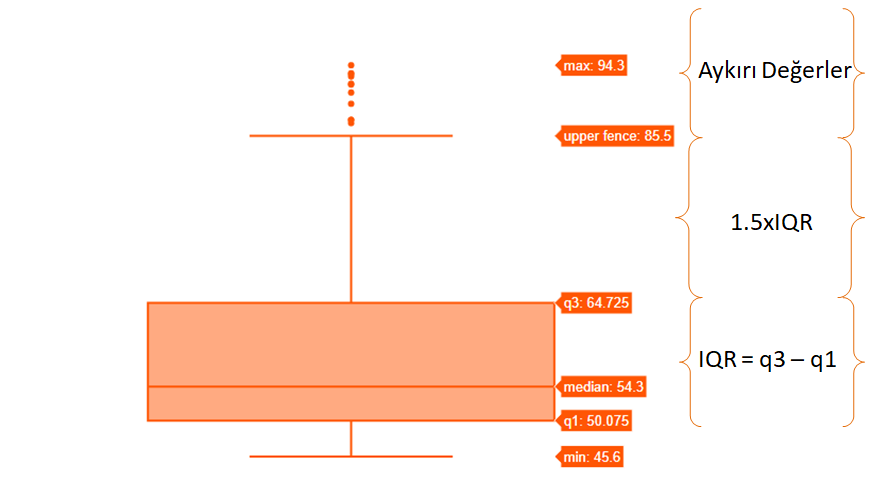

In [26]:
from collections import Counter # bir listedeki elemanların kaç kez geçtiğini saymaya yarayan sınıfıdır.
#anomali (aykırı değer) tespiti yapan kod

def anomaliTespiti(df,ozellik): # df = pandas DataFrame değişkeni burada
    outlier_indices=[]
    for c in ozellik:
        Q1=np.percentile(df[c],25) # 25. percentil hesaplanıyor
        Q3=np.percentile(df[c],75) # 75. percentil hesaplanıyor
        #np.percentile(DataFrame[bakılan sütun], hesaplanmak istenilen percentil değeri) şeklinde kullanılır.
        IQR=Q3-Q1 # ortanca (medyan) hesaplama
        outlier_step=IQR*1.5 # aykırılık sınırı belirleniyor.

        outlier_list_col=df[ (df[c]<Q1-outlier_step) | (df[c]>Q3+outlier_step)].index
        outlier_indices.extend(outlier_list_col)
        # üstteki iki satırı aykırı değerleri outlier.indices=[] dizisine indekleri kaydeder.

    outlier_indices=Counter(outlier_indices)
    multiple_outliers = [
    i
    for i, v in outlier_indices.items()
    if v > 1
]
    return multiple_outliers
        
ozellikler=["yas","boy","kilo"]
indices=anomaliTespiti(veri,ozellikler)
veri_anomali=veri.loc[anomaliTespiti(veri,ozellikler)]
veri_anomali.spor.value_counts()

spor
Basketball        64
Gymnastics        34
Handball           6
Athletics          5
Sailing            3
Diving             3
Shooting           1
Figure Skating     1
Wrestling          1
Name: count, dtype: int64

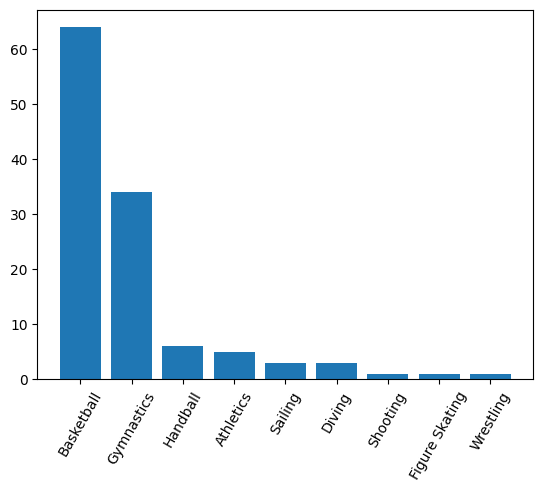

In [27]:
plt.figure()
plt.bar(veri_anomali.spor.value_counts().index,veri_anomali.spor.value_counts().values)
plt.xticks(rotation=60)
plt.show()

In [28]:
veri_anomali.head()

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
6558,Barry Edward Dagger,M,47.0,147.0,41.0,Great Britain,GBR,1984,Summer,Los Angeles,Shooting,"Shooting Men's Air Rifle, 10 metres",Bronze
20181,Magnus Liljedahl,M,46.0,187.0,113.0,United States,USA,2000,Summer,Sydney,Sailing,Sailing Mixed Two Person Keelboat,Gold
22404,"Patrick Joseph ""Pat"" McDonald (McDonnell-)",M,41.0,190.0,120.0,United States,USA,1920,Summer,Antwerpen,Athletics,Athletics Men's 56-pound Weight Throw,Gold
22447,"Matthew John ""Matt"" McGrath",M,48.0,182.0,115.0,United States,USA,1924,Summer,Paris,Athletics,Athletics Men's Hammer Throw,Silver
27889,Bruno Prada,M,40.0,185.0,110.0,Brazil,BRA,2012,Summer,London,Sailing,Sailing Men's Two Person Keelboat,Bronze


In [29]:
veri_gym=veri_anomali[veri_anomali.spor=="Basketball"]

In [30]:
veri_gym

,isim,cinsiyet,yas,boy,kilo,takim,kod,yil,sezon,sehir,spor,etkinlik,madalya
1086,Franjo Arapovi,M,23.0,211.0,120.0,Yugoslavia,YUG,1988,Summer,Seoul,Basketball,Basketball Men's Basketball,Silver
1087,Franjo Arapovi,M,27.0,211.0,120.0,Croatia,CRO,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,Silver
2848,Oleksandr Mykhailovych Bielostienniy,M,21.0,214.0,117.0,Soviet Union,URS,1980,Summer,Moskva,Basketball,Basketball Men's Basketball,Bronze
2849,Oleksandr Mykhailovych Bielostienniy,M,29.0,214.0,117.0,Soviet Union,URS,1988,Summer,Seoul,Basketball,Basketball Men's Basketball,Gold
3465,"Carlos Austin Boozer, Jr.",M,22.0,206.0,117.0,United States,USA,2004,Summer,Athina,Basketball,Basketball Men's Basketball,Bronze
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39644,Rajko ii,M,21.0,210.0,110.0,Yugoslavia,YUG,1976,Summer,Montreal,Basketball,Basketball Men's Basketball,Silver
39645,Rajko ii,M,25.0,210.0,110.0,Yugoslavia,YUG,1980,Summer,Moskva,Basketball,Basketball Men's Basketball,Gold
39646,Rajko ii,M,29.0,210.0,110.0,Yugoslavia,YUG,1984,Summer,Los Angeles,Basketball,Basketball Men's Basketball,Bronze
39736,Eurelijus ukauskas,M,22.0,218.0,115.0,Lithuania,LTU,1996,Summer,Atlanta,Basketball,Basketball Men's Basketball,Bronze


* Anamolinin en çok görüldüğü spor branşları yukarıdaki gibidir.

* Jimnastikte meydana gelen anomali sonucunda veriyi incelediğimizde anomalinin nedeni sporcuların yaşlarının küçük ve kilolarının az olmasından kaynaklıdır.
* Ayrıca jimnastikte meydana gelen anomalilerin hepsi kadın sporcular tarafından gerçekleşmiştir.

* Basketbol oynayan erkek oyuncuların boylarının uzun ve kilolarının fazla olmasından kaynaklı anomali tespit edilmiştir. 

<a id='7'></a>
## Zaman Serilerinde Veri Analizi
* Yıllara Göre Ortalama Yaş, Boy ve Kilo Değişimi
* Yıllara Göre Madalya Sayıları

In [31]:
# tarih_saat sütununda bulunan datetime veri tipine ait veriyi, asıl verinin indeksi yapalım
# pandas kütüphanesinde indeksi datetime veri tipi olan veri setleri ile çalışmak için özel yapılar bulunmaktadır.


### Yıllara Göre Ortalama Yaş, Boy ve Kilo Değişimi

### Yıllara Göre Madalya Sayıları

* Yukarıdaki şekilde görüldüğü gibi 2000'li yıllardan sonra madalya sayılarındaki dalgalanmalar fazla oluyor. Bunun nedeni yaz ve kış olimpiyatlarında yapılan etkinlik sayısının ve buna karşılık gelen madalya sayısının farklılık göstermesidir.

### Yıllara ve Sezonlara Göre Madalya Sayıları